In [1]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import DualMMA as Optimizer
from filtering import Projection, MaxLength
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.3
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta0 = 0.25
eta_dil = eta0
eta_mid = 0.5
eta_ero = 1-eta0
beta0 = 1
r_ml = 8.0
b_max = 4.0
p = 16
opt = Optimizer(x, 2) 
def volume_constraint(x):
    g = np.array([x.sum()/(V_MAX*len(x))-1])
    gradg = np.array(np.ones_like(x))[None,:]/(V_MAX*len(x))
    return g, gradg
def max_length_constraint(x, p, alpha):
    g = np.array([(np.sum(x**p)/len(x))**(1/p)/alpha-1])
    gradg = np.array((np.sum(x**p)/len(x))**(1/p-1)*x**(p-1))[None,:]/(alpha*len(x))
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]]
fil_dil, fil_mid, fil_ero = filters
fil_ml = MaxLength(sens.n1, sens.n2, r_ml, b_max)
alpha = fil_ml.get_alpha()
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters]
    x_ml = fil_ml.apply(x_mid)
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx])
    g1, gradg1_proj = volume_constraint(x_mid)
    g2, gradg2_ml = max_length_constraint(x_ml, p, alpha)
    gradg2_proj = fil_ml.modify_sensitivity_gradgi(gradg2_ml)
    gradf = fil_ero.modify_sensitivity_gradf(gradf_proj)
    gradg1 = fil_mid.modify_sensitivity_gradgi(gradg1_proj)
    gradg2 = fil_mid.modify_sensitivity_gradgi(gradg2_proj)
    g, gradg = np.array([g1[0], g2[0]]), np.concatenate([gradg1, gradg2])
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, g2 = {g[1]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 5.01e+02, g1 = -4.52e-02, g2 = -3.20e-01, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 3.00e+02, g1 = 1.14e-01, g2 = -2.00e-01, norm_inf_x = 5.0e-02, m_nd = 88.83
2 iters, f = 2.16e+02, g1 = -9.56e-03, g2 = -1.91e-01, norm_inf_x = 5.0e-02, m_nd = 82.84
3 iters, f = 1.49e+02, g1 = -1.55e-02, g2 = -7.99e-02, norm_inf_x = 5.0e-02, m_nd = 80.88
4 iters, f = 1.09e+02, g1 = -1.21e-02, g2 = 2.84e-03, norm_inf_x = 5.0e-02, m_nd = 78.96
5 iters, f = 8.94e+01, g1 = -9.04e-03, g2 = 2.23e-02, norm_inf_x = 5.0e-02, m_nd = 77.55
6 iters, f = 7.97e+01, g1 = -5.90e-03, g2 = 9.71e-03, norm_inf_x = 5.0e-02, m_nd = 76.42
7 iters, f = 7.13e+01, g1 = -5.70e-03, g2 = 3.16e-02, norm_inf_x = 5.0e-02, m_nd = 75.76
8 iters, f = 6.75e+01, g1 = -6.74e-03, g2 = 2.03e-02, norm_inf_x = 5.0e-02, m_nd = 73.98
9 iters, f = 6.35e+01, g1 = -7.04e-03, g2 = 3.15e-02, norm_inf_x = 5.0e-02, m_nd = 73.96
10 iters, f = 6.29e+01, g1 = -6.99e-03, g2 = 1.07e-02, norm_inf_x = 5.0e-02, m_nd = 73.18
11 iters, f = 6.1

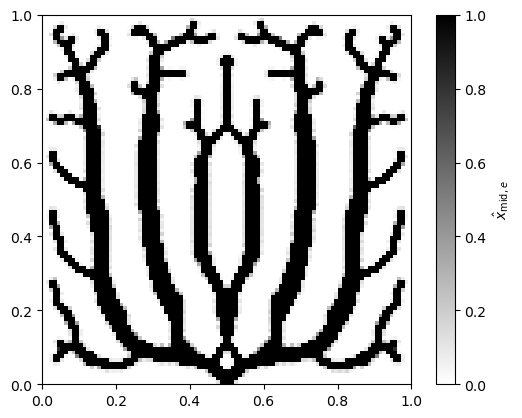

In [2]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

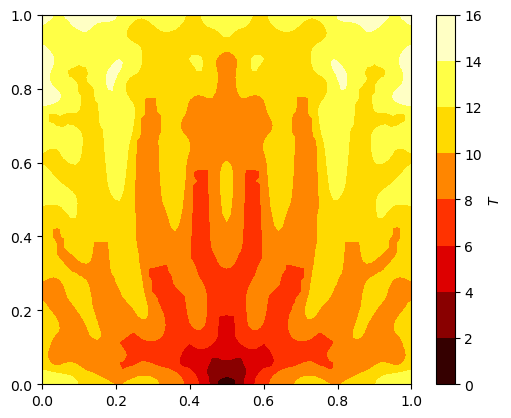

In [3]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [4]:
import numpy as np
from sens_heat3d import SensHeat3D as Sens
from optimizer import DualMMA as Optimizer
from filtering3d import Projection
from scipy.special import erfinv
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.5
eta0 = 0.25
eta_mid = 0.5
eta_ero = 1-eta0
beta0 = 1.0
b_min = 6.0
sigma = b_min/(2*np.sqrt(2)*erfinv(eta_ero))
sens = Sens()
x = np.full(sens.n1*sens.n2*sens.n3, V_MAX)
opt = Optimizer(x, 1) 
def volume_constraint(x):
    g = np.array([x.sum()/len(x) - V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
filters = [Projection(sens.n1, sens.n2, sens.n3, sigma, eta, beta0) for eta in [eta_mid, eta_ero]]
fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_mid, x_ero = [fil.apply(itr, x) for fil in filters]
    f, gradf_proj = sens.compute_obj_sens(x_ero)
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity(gradf_proj)
    gradg = fil_mid.modify_sensitivity(gradg_proj, g=True)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.49e+03, g1 = 0.00e+00, norm_inf_x = 5.0e-02, m_nd = 100.00
1 iters, f = 1.06e+03, g1 = -3.87e-03, norm_inf_x = 5.0e-02, m_nd = 99.18
2 iters, f = 7.73e+02, g1 = -3.28e-03, norm_inf_x = 5.0e-02, m_nd = 97.09
3 iters, f = 5.80e+02, g1 = -2.52e-03, norm_inf_x = 5.0e-02, m_nd = 94.03
4 iters, f = 4.45e+02, g1 = -1.96e-03, norm_inf_x = 5.0e-02, m_nd = 90.33
5 iters, f = 3.49e+02, g1 = -1.62e-03, norm_inf_x = 5.0e-02, m_nd = 86.26
6 iters, f = 2.78e+02, g1 = -1.40e-03, norm_inf_x = 5.0e-02, m_nd = 81.98
7 iters, f = 2.26e+02, g1 = -1.27e-03, norm_inf_x = 5.0e-02, m_nd = 77.57
8 iters, f = 1.86e+02, g1 = -1.20e-03, norm_inf_x = 5.0e-02, m_nd = 72.97
9 iters, f = 1.56e+02, g1 = -1.11e-03, norm_inf_x = 5.0e-02, m_nd = 68.30
10 iters, f = 1.32e+02, g1 = -1.02e-03, norm_inf_x = 5.0e-02, m_nd = 63.24
11 iters, f = 1.32e+02, g1 = -7.06e-04, norm_inf_x = 5.0e-02, m_nd = 60.99
12 iters, f = 1.32e+02, g1 = -5.53e-04, norm_inf_x = 5.0e-02, m_nd = 58.70
13 iters, f = 1.32e+02, g1 = -4.20e

In [5]:
import pyvista as pv
from scipy import ndimage
def export_stl(sens, x, filename="result.stl", iso=0.5, sigma=1.0):
    d = x.reshape((sens.n1, sens.n2, sens.n3), order='F')
    d = np.concatenate([d[::-1], d], axis=0)
    d = np.concatenate([d[:, ::-1], d], axis=1)
    mask = d > iso
    d = np.pad(ndimage.gaussian_filter(mask.astype(float), sigma), 2)
    grid = pv.ImageData(dimensions=np.array(d.shape)+1, spacing=[sens.h]*3, origin=[-sens.h*(sens.n1+2), -sens.h*(sens.n2+2), -sens.h*2])    
    grid.cell_data["d"] = d.flatten(order='F')
    grid.cell_data_to_point_data().contour([iso], "d").smooth_taubin(n_iter=20, pass_band=0.1).save(filename)

In [6]:
export_stl(sens, x_mid)

In [7]:
import numpy as np
from sens_heat3d import SensHeat3D as Sens
from optimizer import DualMMA as Optimizer
from filtering3d import AMFilter
from scipy.special import erfinv
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.5
eta0 = 0.25
eta_mid = 0.5
eta_ero = 1-eta0
beta0 = 1.0
b_min = 6.0
sigma = b_min/(2*np.sqrt(2)*erfinv(eta_ero))
sens = Sens()
x = np.full(sens.n1*sens.n2*sens.n3, V_MAX)
opt = Optimizer(x, 1) 
def volume_constraint(x):
    g = np.array([x.sum()/len(x) - V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
filters = [AMFilter(sens.n1, sens.n2, sens.n3, sigma, eta, beta0) for eta in [eta_mid, eta_ero]]
fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_mid, x_ero = [fil.apply(itr, x) for fil in filters]
    f, gradf_proj = sens.compute_obj_sens(x_ero)
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity(gradf_proj)
    gradg = fil_mid.modify_sensitivity(gradg_proj, g=True)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.45e+03, g1 = -1.90e-04, norm_inf_x = 5.0e-02, m_nd = 100.00
1 iters, f = 1.03e+03, g1 = -1.15e-02, norm_inf_x = 5.0e-02, m_nd = 98.54
2 iters, f = 7.55e+02, g1 = -2.94e-02, norm_inf_x = 5.0e-02, m_nd = 93.05
3 iters, f = 5.67e+02, g1 = -2.62e-02, norm_inf_x = 5.0e-02, m_nd = 89.41
4 iters, f = 4.36e+02, g1 = -6.36e-03, norm_inf_x = 5.0e-02, m_nd = 90.36
5 iters, f = 3.42e+02, g1 = -7.23e-03, norm_inf_x = 5.0e-02, m_nd = 85.68
6 iters, f = 2.73e+02, g1 = -2.26e-03, norm_inf_x = 5.0e-02, m_nd = 84.50
7 iters, f = 2.22e+02, g1 = -2.26e-03, norm_inf_x = 5.0e-02, m_nd = 80.12
8 iters, f = 1.83e+02, g1 = -2.28e-03, norm_inf_x = 5.0e-02, m_nd = 75.82
9 iters, f = 1.53e+02, g1 = -1.80e-03, norm_inf_x = 5.0e-02, m_nd = 70.84
10 iters, f = 1.32e+02, g1 = -1.98e-03, norm_inf_x = 5.0e-02, m_nd = 65.32
11 iters, f = 1.32e+02, g1 = -1.60e-03, norm_inf_x = 5.0e-02, m_nd = 63.00
12 iters, f = 1.32e+02, g1 = -2.02e-03, norm_inf_x = 5.0e-02, m_nd = 60.42
13 iters, f = 1.31e+02, g1 = -1.23

In [8]:
export_stl(sens, x_mid, 'result_am.stl')